In [63]:
import math
import time
import os
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
import h5py
from scipy.fft import fft, fftfreq
from scipy import interpolate

from readh5 import ResultsFilePopulationMeasurement
from matplotlib.ticker import MaxNLocator



f = mticker.ScalarFormatter(useOffset=False, useMathText=True)
g = lambda x,pos : "${}$".format(f._formatSciNotation('%1.10e' % x))


In [64]:
cvel_ms = 2.99792458e08
hartreeTocm = 219474.63


atu_in_s = 2.41888432650516e-17  # atomic time unit in seconds
cm_in_au = atu_in_s * (2.0*math.pi*1e2*cvel_ms)

# Visualize TD-DRMG Results

In [65]:
""" ---results file --- """
data = ResultsFilePopulationMeasurement('/home/cds/vbarandun/Documents/HolsteinHubbard/20mer/FourthOrder/eicosamerFourthOrder_ts0.1fs_m220_16_06_23/excitonicextended.TD.SS.results_state.0.h5')
savepath = '/home/cds/nglaser/proj/project_valentin/plotting/plots/eicosamer/'
""" --- select measurements --- """
population = True
autocorr = True
displacement = False
displacementSquared = False

""" --- time axis --- """
t = np.linspace(0, 7499, 7499)
tstep = 0.1 #timestep in femtoseconds


In [27]:
pop, pop_error = data.extractPopulations()

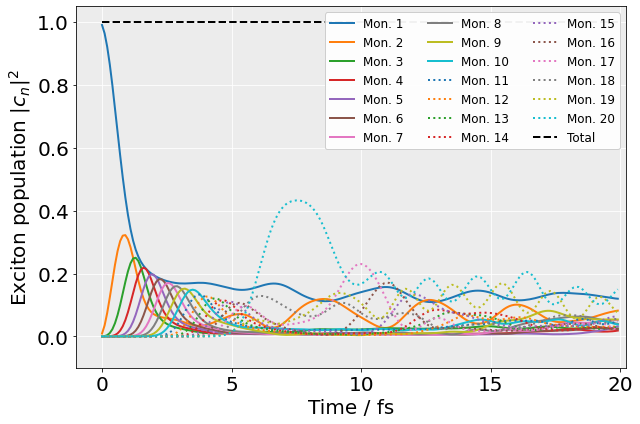

In [67]:
name = 'eicosamer_pop_20fs'
uplim=200
fig, ax = plt.subplots(figsize=[9,6])
ax.set_axisbelow(True)
ax.set_facecolor('0.925')
plt.grid(color='w')
for i in range(0, 10):
    ax.plot(t[:uplim]*tstep, pop[i,:uplim],linewidth=2, label='Mon. ' + str(i+1))
for i in range (10, 20):
    ax.plot(t[:uplim]*tstep, pop[i,:uplim],linewidth=2,linestyle='dotted', label='Mon. ' + str(i+1))
totpop=0
totpop = pop[0,:]
for i in range (1,20):
    totpop = totpop + pop[i,:]
ax.plot(t[:uplim]*tstep, totpop[:uplim], linewidth=2, color='black', linestyle='dashed', label='Total')
ax.set_ylim(-0.1, 1.05)
ax.set_xlim(-1,20.21)
ax.xaxis.set_major_locator(MaxNLocator(5,integer=True))
ax.set_xlabel('Time / fs', fontsize=20)
ax.set_ylabel('Exciton population ' + r'$|c_n|^2$', fontsize=20)
ax.tick_params(axis='both', labelsize=20)
legend = ax.legend(fontsize=12, ncol=3, loc='upper right', framealpha=0.95)
fig.tight_layout()

fig.savefig(savepath + name + '.pdf')
plt.show()

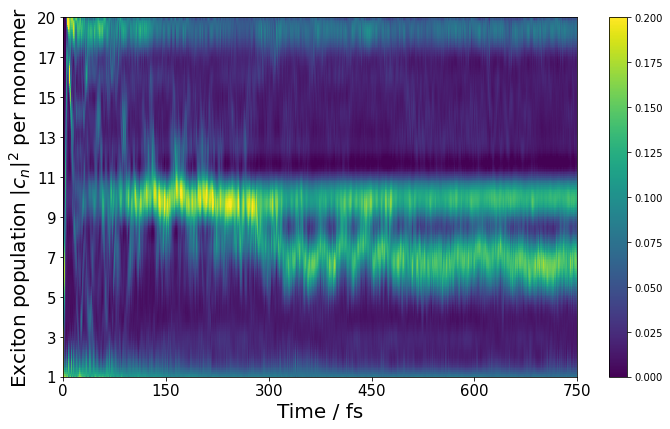

In [73]:
name = 'eicosamer_popmap_full'

""" --- plot poulations --- """
if(population):
    
    
    TwoDPopulations = np.array([pop[0,], pop[1,], pop[2,], pop[3,], pop[4,], pop[5,], pop[6,], pop[7,], pop[8,], pop[9,], pop[10,], pop[11,], pop[12,], pop[13,], pop[14,], pop[15,], pop[16,], pop[17,], pop[18,], pop[19,]], float)

    x_points = np.linspace(1,20,20)
    x_points_input = np.linspace(1,20,200)
    TwoDPopulationsInterpolated = np.zeros((len(x_points_input), len(t)), dtype=float)
    for i in range(len(t)):
        y_points = TwoDPopulations[:,i]
        tck = interpolate.splrep(x_points, y_points)
        TwoDPopulationsInterpolated[:,i] = interpolate.splev(x_points_input, tck)

    fig, ax = plt.subplots(figsize=[10,6])
    pcm = ax.pcolormesh( TwoDPopulationsInterpolated , cmap = 'viridis', vmin=0, vmax=0.2)
    ax.set_yticks(np.linspace(0,200,10))
    ax.set_yticklabels(np.linspace(1,20,10, dtype=int))
    ax.set_xticks(np.linspace(0,7499,6))
    ax.set_xticklabels(np.linspace(0,750,6, dtype=int))
    ax.set_xlabel('Time / fs', fontsize=20)
    ax.set_ylabel('Exciton population ' + r'$|c_n|^2$ per monomer', fontsize=20)
    ax.tick_params(axis='both', labelsize=15)
    fig.colorbar(pcm, ax=ax)
    fig.tight_layout()

    fig.savefig(savepath + name + '.png', dpi=400)
    plt.show()


In [48]:
input = data.extractAutocorrelation()
autocorrelation = input[:,0] + 1j*input[:,1]


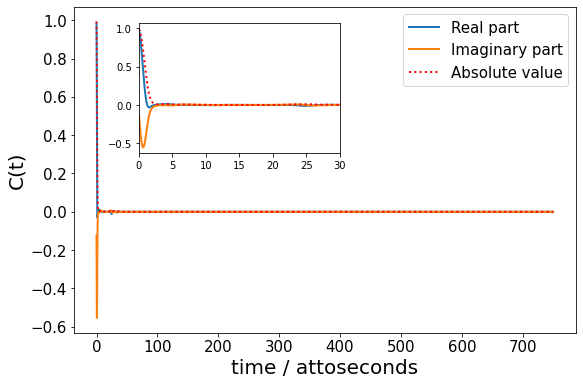

No handles with labels found to put in legend.


795444.2938677


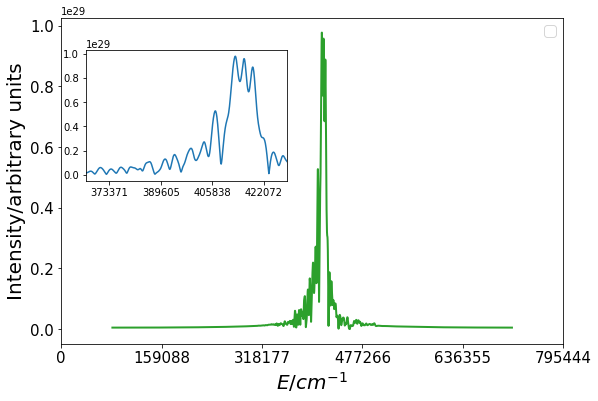

In [49]:
""" --- plot autocorrelation function --- """

fig, ax = plt.subplots(figsize=[9,6])
ax.plot(t*tstep, autocorrelation.real,linewidth=2, label='Real part') 
ax.plot(t*tstep, autocorrelation.imag, linewidth=2, label='Imaginary part')
ax.plot(t*tstep, abs(autocorrelation), linewidth=2, linestyle='dotted', color='red', label='Absolute value')
ax.set_xlabel('time / attoseconds', fontsize=20)
ax.set_ylabel('C(t)', fontsize=20)
ax.tick_params(axis='both', labelsize=15)
legend = ax.legend(fontsize=15)
axIns = ax.inset_axes([0.13, 0.55, 0.4, 0.4])
axIns.plot(t*tstep, autocorrelation.real,linewidth=2) 
axIns.plot(t*tstep, autocorrelation.imag, linewidth=2)
axIns.plot(t*tstep, abs(autocorrelation), linewidth=2, linestyle='dotted', color='red')
axIns.set_xlim(0,30)
plt.show()

#calculating absorption spectrum
tau = 100. #fs
dampingfunc = np.exp(t/tau)
autocorrelation = autocorrelation*dampingfunc
N = len(autocorrelation)
T = len(autocorrelation)*tstep
tFourier = np.linspace(0, T, N)
dt = np.diff(tFourier)[0]
np.pad(autocorrelation, pad_width=(0,len(autocorrelation)))
f = fftfreq(len(tFourier), np.diff(tFourier)[0])
spec = fft(autocorrelation)
spec = np.fft.fftshift(spec)
f = np.fft.fftshift(f)
energyAxis = np.linspace(0,N*106.0733823,6, dtype=int)
print(N*106.0733823)

#plotting spectrum
fig, ax = plt.subplots(figsize=[9,6])
ax.plot(f, np.abs(spec),linewidth=2, color="tab:green")
ax.set_xlabel(r'$E/cm^{-1}$', fontsize=20)  
ax.set_ylabel('Intensity/arbitrary units', fontsize=20)
ax.tick_params(axis='both', labelsize=15)
ax.set_xticks(np.linspace(-2*np.pi,2*np.pi,6))
ax.set_xticklabels(energyAxis)
axIns = ax.inset_axes([0.05, 0.5, 0.4, 0.4])
axIns.plot(f, abs(spec))
axIns.set_xticks(np.linspace(-2*np.pi,2*np.pi,50))
energyAxis = np.linspace(0,N*106.0733823,50, dtype=int)
axIns.set_xticklabels(energyAxis)
axIns.set_xlim(-0.5,0.5)
legend = ax.legend(fontsize=15)
plt.show()

In [50]:
displacement = data.extractDisplacement()

displacementxMonomer0 = displacement[:,0,0]
displacementyMonomer0 = displacement[:,1,0]
displacementthetaMonomer0 = displacement[:,2,0]
displacementxMonomer1 = displacement[:,3,0]
displacementyMonomer1 = displacement[:,4,0]
displacementthetaMonomer1 = displacement[:,5,0]
displacementxMonomer2 = displacement[:,6,0]
displacementyMonomer2 = displacement[:,7,0]
displacementthetaMonomer2 = displacement[:,8,0]
displacementxMonomer3 = displacement[:,9,0]
displacementyMonomer3 = displacement[:,10,0]
displacementthetaMonomer3 = displacement[:,11,0]
displacementxMonomer4 = displacement[:,12,0]
displacementyMonomer4 = displacement[:,13,0]
displacementthetaMonomer4 = displacement[:,14,0]
displacementxMonomer5 = displacement[:,15,0]
displacementyMonomer5 = displacement[:,16,0]
displacementthetaMonomer5 = displacement[:,17,0]
displacementxMonomer6 = displacement[:,18,0]
displacementyMonomer6 = displacement[:,19,0]
displacementthetaMonomer6 = displacement[:,20,0]
displacementxMonomer7 = displacement[:,21,0]
displacementyMonomer7 = displacement[:,22,0]
displacementthetaMonomer7 = displacement[:,23,0]
displacementxMonomer8 = displacement[:,24,0]
displacementyMonomer8 = displacement[:,25,0]
displacementthetaMonomer8 = displacement[:,26,0]
displacementxMonomer9 = displacement[:,27,0]
displacementyMonomer9 = displacement[:,28,0]
displacementthetaMonomer9 = displacement[:,29,0]
displacementxMonomer10 = displacement[:,30,0]
displacementyMonomer10 = displacement[:,31,0]
displacementthetaMonomer10 = displacement[:,32,0]
displacementxMonomer11 = displacement[:,33,0]
displacementyMonomer11 = displacement[:,34,0]
displacementthetaMonomer11 = displacement[:,35,0]
displacementxMonomer12 = displacement[:,36,0]
displacementyMonomer12 = displacement[:,37,0]
displacementthetaMonomer12 = displacement[:,38,0]
displacementxMonomer13 = displacement[:,39,0]
displacementyMonomer13 = displacement[:,40,0]
displacementthetaMonomer13 = displacement[:,41,0]
displacementxMonomer14 = displacement[:,42,0]
displacementyMonomer14 = displacement[:,43,0]
displacementthetaMonomer14 = displacement[:,44,0]
displacementxMonomer15 = displacement[:,45,0]
displacementyMonomer15 = displacement[:,46,0]
displacementthetaMonomer15 = displacement[:,47,0]
displacementxMonomer16 = displacement[:,48,0]
displacementyMonomer16 = displacement[:,49,0]
displacementthetaMonomer16 = displacement[:,50,0]
displacementxMonomer17 = displacement[:,51,0]
displacementyMonomer17 = displacement[:,52,0]
displacementthetaMonomer17 = displacement[:,53,0]
displacementxMonomer18 = displacement[:,54,0]
displacementyMonomer18 = displacement[:,55,0]
displacementthetaMonomer18 = displacement[:,56,0]
displacementxMonomer19 = displacement[:,57,0]
    

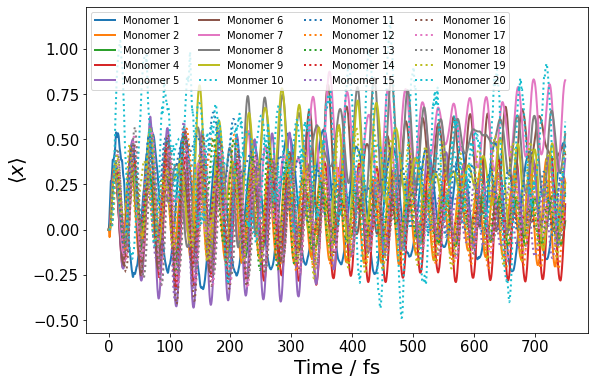

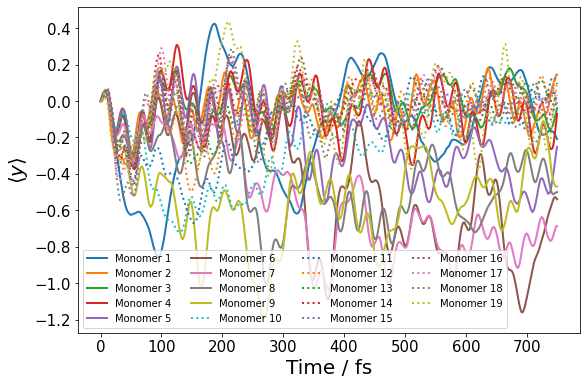

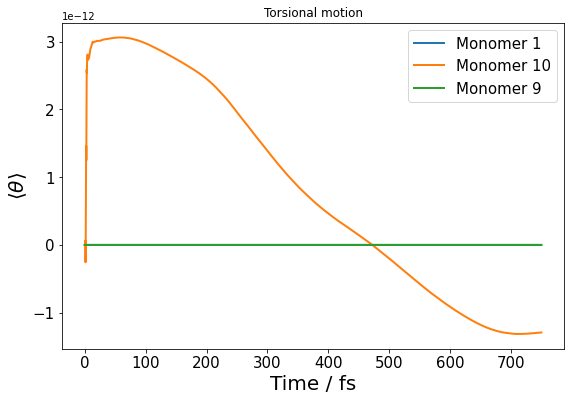

In [57]:

    #plotting x-mode
    
    fig, ax = plt.subplots(figsize=[9,6])
    ax.plot(t*tstep, displacementxMonomer0,linewidth=2, label = 'Monomer 1')
    ax.plot(t*tstep, displacementxMonomer1,linewidth=2, label = 'Monomer 2')
    ax.plot(t*tstep, displacementxMonomer2,linewidth=2, label = 'Monomer 3')
    ax.plot(t*tstep, displacementxMonomer3,linewidth=2, label = 'Monomer 4')
    ax.plot(t*tstep, displacementxMonomer4,linewidth=2, label = 'Monomer 5')
    ax.plot(t*tstep, displacementxMonomer5,linewidth=2, label = 'Monomer 6')
    ax.plot(t*tstep, displacementxMonomer6,linewidth=2, label = 'Monomer 7')
    ax.plot(t*tstep, displacementxMonomer7,linewidth=2, label = 'Monomer 8')
    ax.plot(t*tstep, displacementxMonomer8,linewidth=2, label = 'Monomer 9')
    ax.plot(t*tstep, displacementxMonomer9,linewidth=2, label = 'Monmer 10', linestyle='dotted')
    ax.plot(t*tstep, displacementxMonomer10,linewidth=2, label = 'Monomer 11', linestyle='dotted')
    ax.plot(t*tstep, displacementxMonomer11,linewidth=2, label = 'Monomer 12', linestyle='dotted')
    ax.plot(t*tstep, displacementxMonomer12,linewidth=2, label = 'Monomer 13', linestyle='dotted')
    ax.plot(t*tstep, displacementxMonomer13,linewidth=2, label = 'Monomer 14', linestyle='dotted')
    ax.plot(t*tstep, displacementxMonomer14,linewidth=2, label = 'Monomer 15', linestyle='dotted')
    ax.plot(t*tstep, displacementxMonomer15,linewidth=2, label = 'Monomer 16', linestyle='dotted')
    ax.plot(t*tstep, displacementxMonomer16,linewidth=2, label = 'Monomer 17', linestyle='dotted')
    ax.plot(t*tstep, displacementxMonomer17,linewidth=2, label = 'Monomer 18', linestyle='dotted')
    ax.plot(t*tstep, displacementxMonomer18,linewidth=2, label = 'Monomer 19', linestyle='dotted')
    ax.plot(t*tstep, displacementxMonomer19,linewidth=2, label = 'Monomer 20', linestyle='dotted')
    ax.set_xlabel('Time / fs', fontsize=20)
    ax.set_ylabel(r'$\langle x \rangle$', fontsize=20)
    ax.tick_params(axis='both', labelsize=15)
    legend = ax.legend(fontsize=10, ncol=4)
    plt.show()
    
    #plotting y-mode
    fig, ax = plt.subplots(figsize=[9,6])
    ax.plot(t*tstep, displacementyMonomer0,linewidth=2, label = 'Monomer 1')
    ax.plot(t*tstep, displacementyMonomer1,linewidth=2, label = 'Monomer 2')
    ax.plot(t*tstep, displacementyMonomer2,linewidth=2, label = 'Monomer 3')
    ax.plot(t*tstep, displacementyMonomer3,linewidth=2, label = 'Monomer 4')
    ax.plot(t*tstep, displacementyMonomer4,linewidth=2, label = 'Monomer 5')
    ax.plot(t*tstep, displacementyMonomer5,linewidth=2, label = 'Monomer 6')
    ax.plot(t*tstep, displacementyMonomer6,linewidth=2, label = 'Monomer 7')
    ax.plot(t*tstep, displacementyMonomer7,linewidth=2, label = 'Monomer 8')
    ax.plot(t*tstep, displacementyMonomer8,linewidth=2, label = 'Monomer 9')
    ax.plot(t*tstep, displacementyMonomer9,linewidth=2, label = 'Monomer 10', linestyle='dotted')
    ax.plot(t*tstep, displacementyMonomer10,linewidth=2, label = 'Monomer 11', linestyle='dotted')
    ax.plot(t*tstep, displacementyMonomer11,linewidth=2, label = 'Monomer 12', linestyle='dotted')
    ax.plot(t*tstep, displacementyMonomer12,linewidth=2, label = 'Monomer 13', linestyle='dotted')
    ax.plot(t*tstep, displacementyMonomer13,linewidth=2, label = 'Monomer 14', linestyle='dotted')
    ax.plot(t*tstep, displacementyMonomer14,linewidth=2, label = 'Monomer 15', linestyle='dotted')
    ax.plot(t*tstep, displacementyMonomer15,linewidth=2, label = 'Monomer 16', linestyle='dotted')
    ax.plot(t*tstep, displacementyMonomer16,linewidth=2, label = 'Monomer 17', linestyle='dotted')
    ax.plot(t*tstep, displacementyMonomer17,linewidth=2, label = 'Monomer 18', linestyle='dotted')
    ax.plot(t*tstep, displacementyMonomer18,linewidth=2, label = 'Monomer 19', linestyle='dotted')
    ax.set_xlabel('Time / fs', fontsize=20)
    ax.set_ylabel(r'$\langle y \rangle$', fontsize=20)
    ax.tick_params(axis='both', labelsize=15)
    legend = ax.legend(fontsize=10, ncol=4)
    plt.show()


    #plotting theta-mode
    fig, ax = plt.subplots(figsize=[9,6])
    ax.set_title('Torsional motion')
    ax.plot(t*tstep, displacementthetaMonomer0,linewidth=2, label = 'Monomer 1')
    #ax.plot(t*tstep, displacementthetaMonomer1,linewidth=2, label = 'Monomer 2')
    #ax.plot(t*tstep, displacementthetaMonomer2,linewidth=2, label = 'Monomer 3')
    #ax.plot(t*tstep, displacementthetaMonomer3,linewidth=2, label = 'Monomer 4')
    ax.plot(t*tstep, displacementthetaMonomer9,linewidth=2, label = 'Monomer 10')
    #ax.plot(t*tstep, displacementthetaMonomer5,linewidth=2, label = 'Monomer 6')
    #ax.plot(t*tstep, displacementthetaMonomer6,linewidth=2, label = 'Monomer 7')
    #ax.plot(t*tstep, displacementthetaMonomer7,linewidth=2, label = 'Monomer 8')
    ax.plot(t*tstep, displacementthetaMonomer18,linewidth=2, label = 'Monomer 9')
    ax.set_xlabel('Time / fs', fontsize=20)
    ax.set_ylabel(r'$\langle \theta \rangle$', fontsize=20)
    ax.tick_params(axis='both', labelsize=15)
    legend = ax.legend(fontsize=15)
    plt.show()

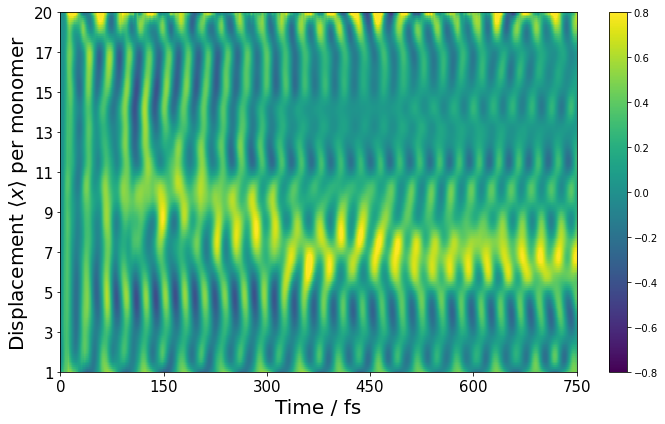

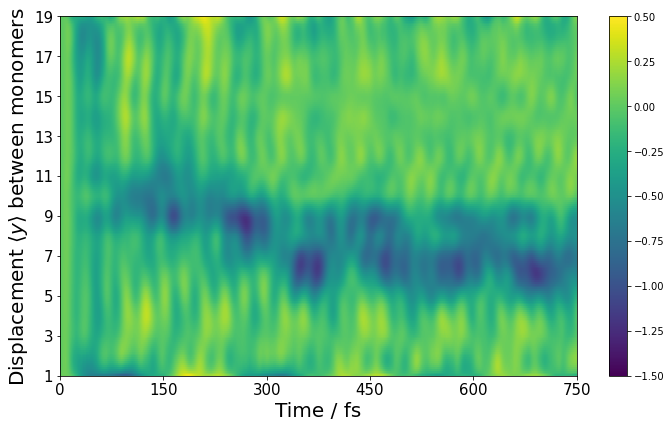

In [74]:


""" --- plot displacement --- """





TwoDxDisplacement = np.array([displacementxMonomer0, displacementxMonomer1, displacementxMonomer2, displacementxMonomer3, displacementxMonomer4, displacementxMonomer5, displacementxMonomer6, displacementxMonomer7, displacementxMonomer8, displacementxMonomer9, displacementxMonomer10, displacementxMonomer11, displacementxMonomer12, displacementxMonomer13, displacementxMonomer14, displacementxMonomer15, displacementxMonomer16, displacementxMonomer17, displacementxMonomer18, displacementxMonomer19], float)

x_points = np.linspace(0,19,20)
x_points_input = np.linspace(0,19,200)
TwoDxDisplacementInterpolated = np.zeros((len(x_points_input), len(t)), dtype=float)
for i in range(len(t)):
    y_points = TwoDxDisplacement[:,i]
    tck = interpolate.splrep(x_points, y_points)
    TwoDxDisplacementInterpolated[:,i] = interpolate.splev(x_points_input, tck)

name = 'eicosamer_xdispmap'
fig, ax = plt.subplots(figsize=[10,6])
pcm = ax.pcolormesh( TwoDxDisplacementInterpolated , cmap = 'viridis', vmin=-0.8, vmax=0.8)
ax.set_yticks(np.linspace(0,200,10))
ax.set_yticklabels(np.linspace(1,20,10, dtype=int))
ax.set_xticks(np.linspace(0,7499,6))
ax.set_xticklabels(np.linspace(0,750,6, dtype=int))
ax.set_xlabel('Time / fs', fontsize=20)
ax.set_ylabel('Displacement ' + r'$\langle x \rangle$ per monomer', fontsize=20)
ax.tick_params(axis='both', labelsize=15)
fig.colorbar(pcm, ax=ax)
fig.tight_layout()
fig.savefig(savepath + name + '.png', dpi=400)
plt.show()



TwoDyDisplacement = np.array([displacementyMonomer0, displacementyMonomer1, displacementyMonomer2, displacementyMonomer3, displacementyMonomer4, displacementyMonomer5, displacementyMonomer6, displacementyMonomer7, displacementyMonomer8, displacementyMonomer9, displacementyMonomer10, displacementyMonomer11, displacementyMonomer12, displacementyMonomer13, displacementyMonomer14, displacementyMonomer15, displacementyMonomer16, displacementyMonomer17, displacementyMonomer18], float)

x_points = np.linspace(0,18,19)
x_points_input = np.linspace(0,18,190)
TwoDyDisplacementInterpolated = np.zeros((len(x_points_input), len(t)), dtype=float)
for i in range(len(t)):
    y_points = TwoDyDisplacement[:,i]
    tck = interpolate.splrep(x_points, y_points)
    TwoDyDisplacementInterpolated[:,i] = interpolate.splev(x_points_input, tck)


name = 'eicosamer_ydispmap'

fig, ax = plt.subplots(figsize=[10,6])
pcm = ax.pcolormesh( TwoDyDisplacementInterpolated , cmap = 'viridis', vmin=-1.5, vmax=0.5)
ax.set_yticks(np.linspace(0,190,10))
ax.set_yticklabels(np.linspace(1,19,10, dtype=int))
ax.set_xticks(np.linspace(0,7499,6))
ax.set_xticklabels(np.linspace(0,750,6, dtype=int))
ax.set_ylabel('Displacement ' + r'$\langle y \rangle$ between monomers', fontsize=20)
ax.set_xlabel('Time / fs', fontsize=20)
ax.tick_params(axis='both', labelsize=15)
fig.colorbar(pcm, ax=ax)
fig.tight_layout()
fig.savefig(savepath + name + '.png', dpi=400)
plt.show()


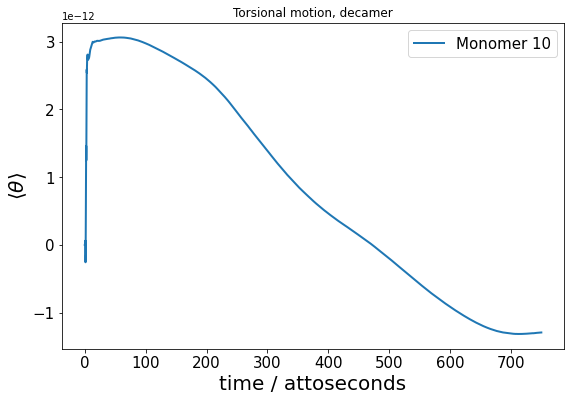

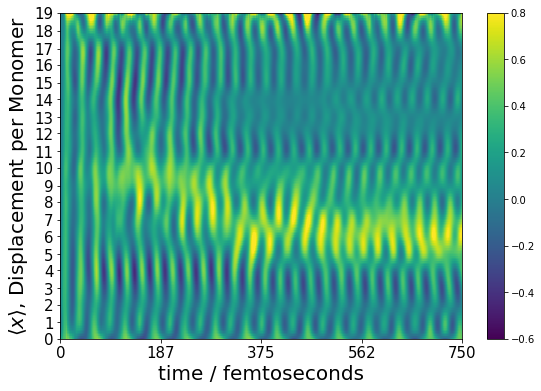

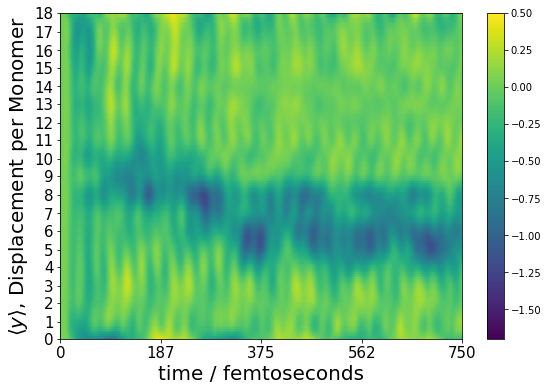

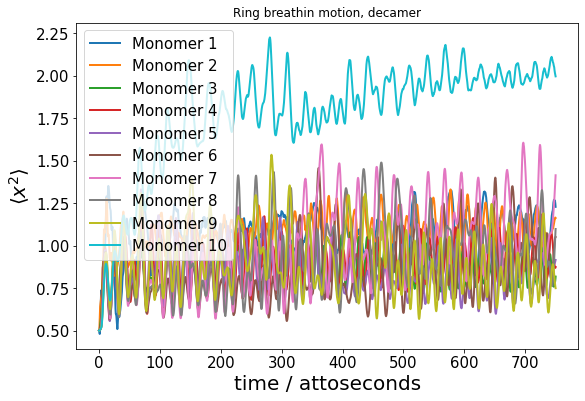

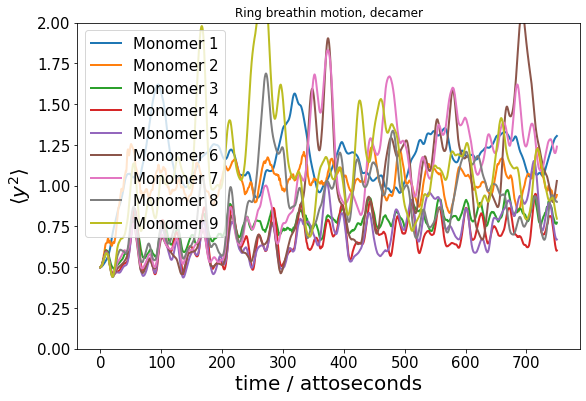

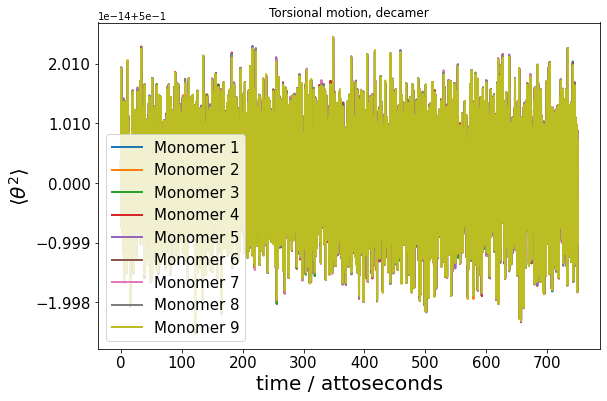

In [55]:

    




""" --- plot squared displacement --- """
if(True):
    
    displacementSquared = data.extractDisplacementSquared()

    displacementSquaredxMonomer0 = displacementSquared[:,0,0]
    displacementSquaredyMonomer0 = displacementSquared[:,1,0]
    displacementSquaredthetaMonomer0 = displacementSquared[:,2,0]
    displacementSquaredxMonomer1 = displacementSquared[:,3,0]
    displacementSquaredyMonomer1 = displacementSquared[:,4,0]
    displacementSquaredthetaMonomer1 = displacementSquared[:,5,0]
    displacementSquaredxMonomer2 = displacementSquared[:,6,0]
    displacementSquaredyMonomer2 = displacementSquared[:,7,0]
    displacementSquaredthetaMonomer2 = displacementSquared[:,8,0]
    displacementSquaredxMonomer3 = displacementSquared[:,9,0]
    displacementSquaredyMonomer3 = displacementSquared[:,10,0]
    displacementSquaredthetaMonomer3 = displacementSquared[:,11,0]
    displacementSquaredxMonomer4 = displacementSquared[:,12,0]
    displacementSquaredyMonomer4 = displacementSquared[:,13,0]
    displacementSquaredthetaMonomer4 = displacementSquared[:,14,0]
    displacementSquaredxMonomer5 = displacementSquared[:,15,0]
    displacementSquaredyMonomer5 = displacementSquared[:,16,0]
    displacementSquaredthetaMonomer5 = displacementSquared[:,17,0]
    displacementSquaredxMonomer6 = displacementSquared[:,18,0]
    displacementSquaredyMonomer6 = displacementSquared[:,19,0]
    displacementSquaredthetaMonomer6 = displacementSquared[:,20,0]
    displacementSquaredxMonomer7 = displacementSquared[:,21,0]
    displacementSquaredyMonomer7 = displacementSquared[:,22,0]
    displacementSquaredthetaMonomer7 = displacementSquared[:,23,0]
    displacementSquaredxMonomer8 = displacementSquared[:,24,0]
    displacementSquaredyMonomer8 = displacementSquared[:,25,0]
    displacementSquaredthetaMonomer8 = displacementSquared[:,26,0]
    displacementSquaredxMonomer9 = displacementSquared[:,27,0]

    
    
    #plotting x-mode
    fig, ax = plt.subplots(figsize=[9,6])
    ax.set_title('Ring breathin motion, decamer')
    ax.plot(t*tstep, displacementSquaredxMonomer0,linewidth=2, label = 'Monomer 1')
    ax.plot(t*tstep, displacementSquaredxMonomer1,linewidth=2, label = 'Monomer 2')
    ax.plot(t*tstep, displacementSquaredxMonomer2,linewidth=2, label = 'Monomer 3')
    ax.plot(t*tstep, displacementSquaredxMonomer3,linewidth=2, label = 'Monomer 4')
    ax.plot(t*tstep, displacementSquaredxMonomer4,linewidth=2, label = 'Monomer 5')
    ax.plot(t*tstep, displacementSquaredxMonomer5,linewidth=2, label = 'Monomer 6')
    ax.plot(t*tstep, displacementSquaredxMonomer6,linewidth=2, label = 'Monomer 7')
    ax.plot(t*tstep, displacementSquaredxMonomer7,linewidth=2, label = 'Monomer 8')
    ax.plot(t*tstep, displacementSquaredxMonomer8,linewidth=2, label = 'Monomer 9')
    ax.plot(t*tstep, displacementSquaredxMonomer9,linewidth=2, label = 'Monomer 10')
    ax.set_xlabel('time / attoseconds', fontsize=20)  
    ax.set_ylabel(r'$\langle x^2 \rangle$', fontsize=20)
    ax.tick_params(axis='both', labelsize=15)
    legend = ax.legend(fontsize=15)
    plt.show()

    #plotting y-mode
    fig, ax = plt.subplots(figsize=[9,6])
    ax.set_title('Ring breathin motion, decamer')
    ax.plot(t*tstep, displacementSquaredyMonomer0,linewidth=2, label = 'Monomer 1')
    ax.plot(t*tstep, displacementSquaredyMonomer1,linewidth=2, label = 'Monomer 2')
    ax.plot(t*tstep, displacementSquaredyMonomer2,linewidth=2, label = 'Monomer 3')
    ax.plot(t*tstep, displacementSquaredyMonomer3,linewidth=2, label = 'Monomer 4')
    ax.plot(t*tstep, displacementSquaredyMonomer4,linewidth=2, label = 'Monomer 5')
    ax.plot(t*tstep, displacementSquaredyMonomer5,linewidth=2, label = 'Monomer 6')
    ax.plot(t*tstep, displacementSquaredyMonomer6,linewidth=2, label = 'Monomer 7')
    ax.plot(t*tstep, displacementSquaredyMonomer7,linewidth=2, label = 'Monomer 8')
    ax.plot(t*tstep, displacementSquaredyMonomer8,linewidth=2, label = 'Monomer 9')
    ax.set_ylim(0,2)
    ax.set_xlabel('time / attoseconds', fontsize=20)  
    ax.set_ylabel(r'$\langle y^2 \rangle$', fontsize=20)
    ax.tick_params(axis='both', labelsize=15)
    legend = ax.legend(fontsize=15)
    plt.show()

    #plotting theta-mode
    fig, ax = plt.subplots(figsize=[9,6])
    ax.set_title('Torsional motion, decamer')
    ax.plot(t*tstep, displacementSquaredthetaMonomer0,linewidth=2, label = 'Monomer 1')
    ax.plot(t*tstep, displacementSquaredthetaMonomer1,linewidth=2, label = 'Monomer 2')
    ax.plot(t*tstep, displacementSquaredthetaMonomer2,linewidth=2, label = 'Monomer 3')
    ax.plot(t*tstep, displacementSquaredthetaMonomer3,linewidth=2, label = 'Monomer 4')
    ax.plot(t*tstep, displacementSquaredthetaMonomer4,linewidth=2, label = 'Monomer 5')
    ax.plot(t*tstep, displacementSquaredthetaMonomer5,linewidth=2, label = 'Monomer 6')
    ax.plot(t*tstep, displacementSquaredthetaMonomer6,linewidth=2, label = 'Monomer 7')
    ax.plot(t*tstep, displacementSquaredthetaMonomer7,linewidth=2, label = 'Monomer 8')
    ax.plot(t*tstep, displacementSquaredthetaMonomer8,linewidth=2, label = 'Monomer 9')
    ax.set_xlabel('time / attoseconds', fontsize=20)  
    ax.set_ylabel(r'$\langle \theta^2 \rangle$', fontsize=20)
    ax.tick_params(axis='both', labelsize=15)
    legend = ax.legend(fontsize=15)
    plt.show()
    


